In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_parquet("../data/processed/customer_churn_features")

print(df.shape)

df.head()

(1000000, 40)


,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure_months,contract,...,credit_score,churn,churn_label,tenure_years,monthly_charge_per_tenure,is_high_monthly_charge,is_new_customer,is_low_satisfaction,is_multi_service_customer,is_month_to_month
0,cust0000512286,2023-10-12 12:54:04.116498,18.0,female,24850.01,college,married,0.0,72.0,two_year,...,649.0,0.0,0,6.000000,1.105000,0,0,0,0,0
1,cust0000512287,2022-07-02 12:54:04.116503,41.0,male,42363.61,college,single,0.0,12.0,one_year,...,634.0,0.0,0,1.000000,6.440000,0,0,0,0,0
2,cust0000512288,2026-01-01 12:54:04.116509,55.0,female,52368.07,master,single,0.0,13.0,two_year,...,746.0,0.0,0,1.083333,9.718462,1,0,0,1,0
3,cust0000512289,2022-02-24 12:54:04.116514,44.0,female,20000.00,master,married,2.0,41.0,one_year,...,694.0,0.0,0,3.416667,1.267805,0,0,1,0,0
4,cust0000512290,2022-05-07 12:54:04.116520,45.0,female,100501.49,high_school,married,0.0,32.0,two_year,...,566.0,0.0,0,2.666667,1.898125,0,0,1,0,0


In [4]:
df.columns

Index(['customer_id', 'signup_date', 'age', 'gender', 'annual_income',
       'education', 'marital_status', 'dependents', 'tenure_months',
       'contract', 'payment_method', 'paperless_billing', 'senior_citizen',
       'monthly_charges', 'total_charges', 'num_services', 'has_phone_service',
       'has_internet_service', 'has_online_security', 'has_online_backup',
       'has_device_protection', 'has_tech_support', 'has_streaming_tv',
       'has_streaming_movies', 'customer_satisfaction', 'num_complaints',
       'num_service_calls', 'late_payments', 'avg_monthly_gb',
       'days_since_last_interaction', 'credit_score', 'churn', 'churn_label',
       'tenure_years', 'monthly_charge_per_tenure', 'is_high_monthly_charge',
       'is_new_customer', 'is_low_satisfaction', 'is_multi_service_customer',
       'is_month_to_month'],
      dtype='object')

In [5]:
df.isnull().sum()

customer_id                        0
signup_date                        0
age                                0
gender                             0
annual_income                  29959
education                          0
marital_status                     0
dependents                         0
tenure_months                      0
contract                           0
payment_method                     0
paperless_billing                  0
senior_citizen                     0
monthly_charges                    0
total_charges                      0
num_services                       0
has_phone_service                  0
has_internet_service               0
has_online_security                0
has_online_backup                  0
has_device_protection              0
has_tech_support                   0
has_streaming_tv                   0
has_streaming_movies               0
customer_satisfaction          19921
num_complaints                 29906
num_service_calls                  0
l

In [6]:
missing_summary = (
    df.isnull().sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing_summary["missing_percent"] = (missing_summary["missing_count"] / len(df)) * 100

missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values(
    "missing_percent", ascending=False
)

missing_summary

,column,missing_count,missing_percent
28,avg_monthly_gb,50012,5.0012
30,credit_score,40395,4.0395
4,annual_income,29959,2.9959
25,num_complaints,29906,2.9906
24,customer_satisfaction,19921,1.9921


## Do Senior Citizens churn more than non senior citizens?

<Axes: xlabel='senior_citizen', ylabel='count'>

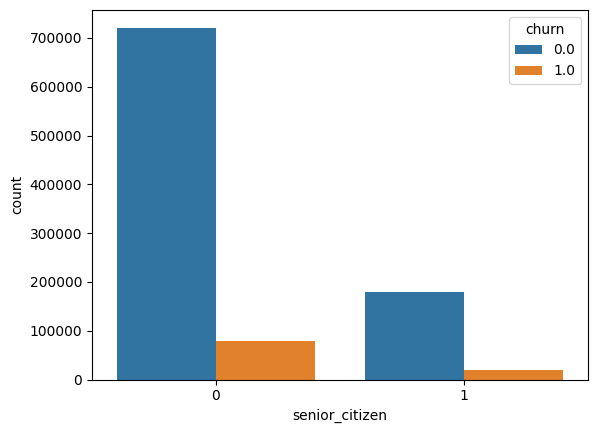

In [7]:
#lets see if senior citizens are more likely to churn
sns.countplot(data=df, x='senior_citizen', hue='churn')


## we can see that the number of senior citizens that churn are higher than non senior citizens

## Does annual income impact churn rate?

<Axes: xlabel='churn', ylabel='annual_income'>

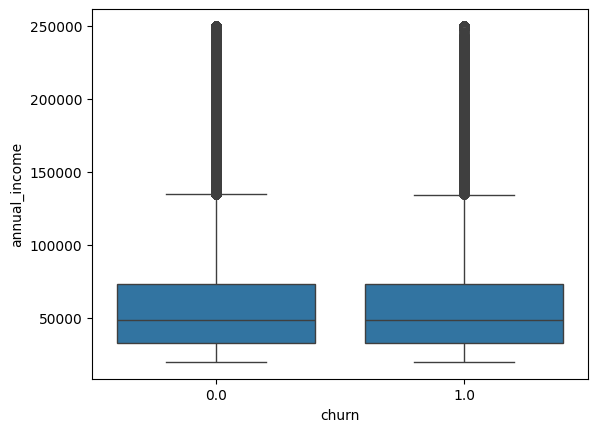

In [9]:
#we could see if the income level of the customer has an effect on churn rate
sns.boxplot(data=df, x='churn', y='annual_income')

## Interpretation

Annual income doesn't effect churn rate

## Does Customer Satisfaction effect churn rate?

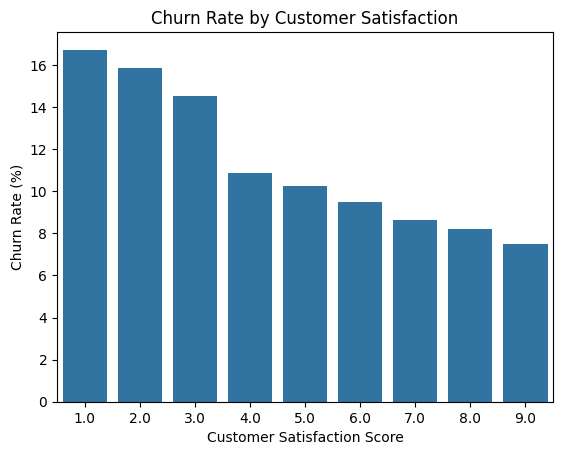

In [10]:
satisfaction_churn = (
    df.groupby("customer_satisfaction")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean")
    )
    .reset_index()
)

satisfaction_churn["churn_rate"] = satisfaction_churn["churn_rate"] * 100

satisfaction_churn

sns.barplot(
    data=satisfaction_churn,
    x="customer_satisfaction",
    y="churn_rate"
)

plt.title("Churn Rate by Customer Satisfaction")
plt.xlabel("Customer Satisfaction Score")
plt.ylabel("Churn Rate (%)")
plt.show()

## Interpretation

Yes, customer satisfaction does show an increased churn rate when at a score of 3 or lower

## How imbalanced is the dataset?

<Axes: xlabel='churn', ylabel='count'>

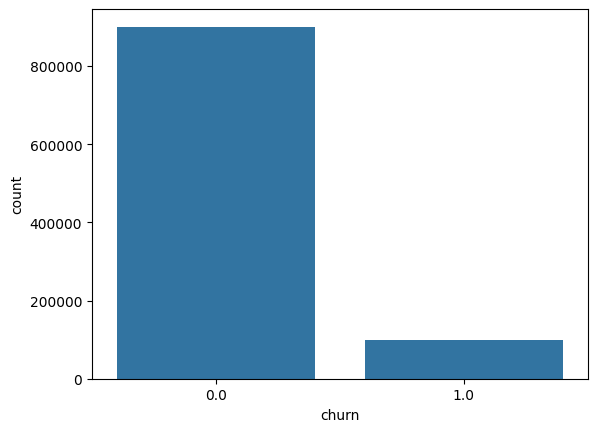

In [11]:
sns.countplot(data=df, x='churn')

## Interpretation 

Try undersampling when doing modeling first in order to preserve the real data

In [12]:
df["churn_label"].value_counts(normalize=True) * 100

churn_label
0    90.0773
1     9.9227
Name: proportion, dtype: float64

## Does Age effect churn rate?

<Axes: xlabel='churn', ylabel='age'>

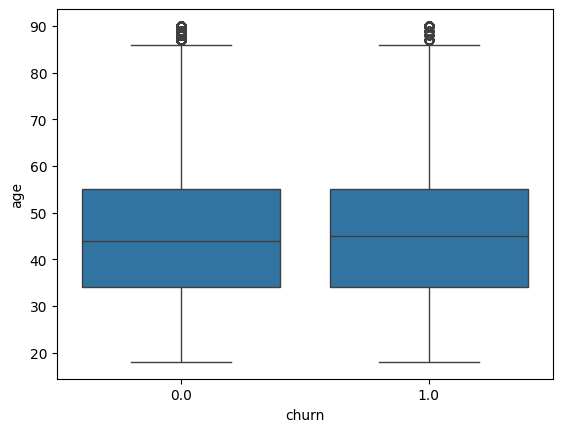

In [13]:
#lets look at how age affects churn rate
sns.boxplot(data=df, x='churn', y='age')

## Interpretation

Age doesn't effect churn rate

## Does increasing tenure months mean less churn rate?

<Axes: xlabel='churn', ylabel='tenure_months'>

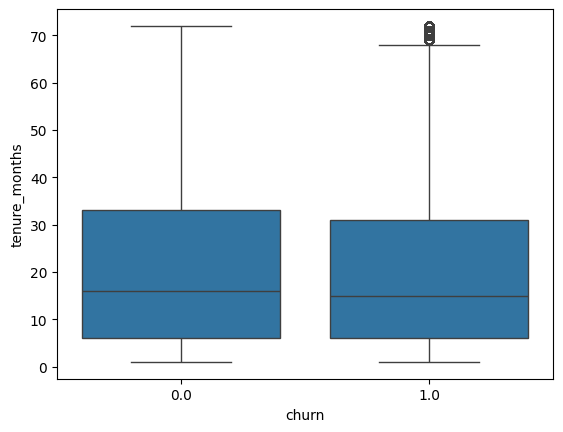

In [14]:
#lets see how tenure affects churn rate
sns.boxplot(data=df, x='churn', y='tenure_months')

## Interpretation

No, increasing tenure months doesn't decrease likelihood of churning

In [16]:
#lets look at all unique values for contract type
df['contract'].value_counts()

contract
one_year          550468
two_year          429540
month_to_month     19992
Name: count, dtype: int64

## Does contract type effect churn rate?

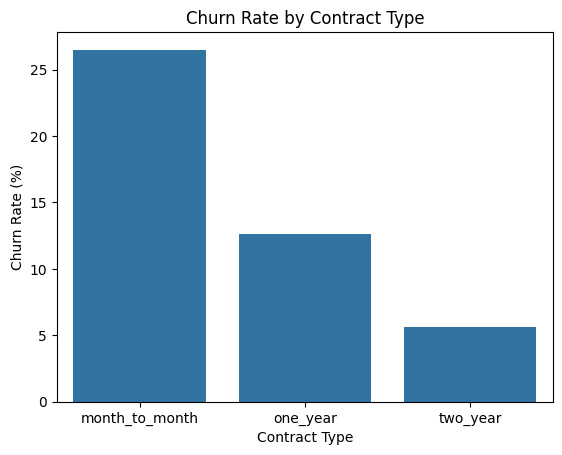

In [17]:
contract_churn = (
    df.groupby("contract")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean")
    )
    .reset_index()
)

contract_churn["churn_rate"] = contract_churn["churn_rate"] * 100

contract_churn.sort_values("churn_rate", ascending=False)

sns.barplot(
    data=contract_churn,
    x="contract",
    y="churn_rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

## Interpretation

Yes, we see that the churn rate of month_to_month contracts are around 25% compared to the next lowest of around 13%, both are very high compared to the next lowest of 5% for 2 year contracts

## Does contract type and tenure months effect churn rate?

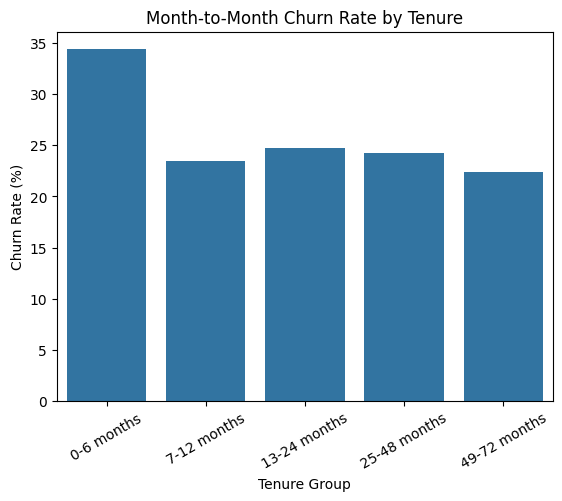

In [18]:
#now lets look at how the month_to_month churn rate is affected by tenure 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to month-to-month customers only
mtm = df[df["contract"] == "month_to_month"].copy()

# Create tenure groups
mtm["tenure_group"] = pd.cut(
    mtm["tenure_months"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["0-6 months", "7-12 months", "13-24 months", "25-48 months", "49-72 months"],
    include_lowest=True
)

# Calculate churn rate by tenure group
mtm_tenure_churn = (
    mtm.groupby("tenure_group", observed=True)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean")
    )
    .reset_index()
)

mtm_tenure_churn["churn_rate"] = mtm_tenure_churn["churn_rate"] * 100

mtm_tenure_churn

sns.barplot(
    data=mtm_tenure_churn,
    x="tenure_group",
    y="churn_rate"
)

plt.title("Month-to-Month Churn Rate by Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

## Interpretation

We see that month to month contracts along with only being a customer from 0-6 months also affects churn rate by around 15% more at around 34%

## Does decreasing the bins show that churn rate isn't from 0-6 months but actually at 0-3 months?

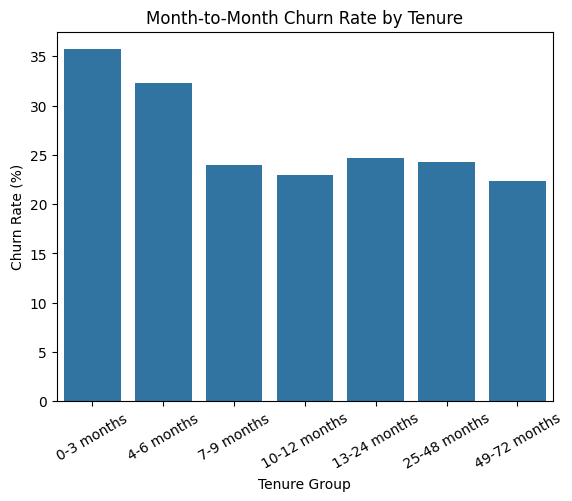

In [19]:
#lets look at smaller bins for the time frame
mtm["tenure_group"] = pd.cut(
    mtm["tenure_months"],
    bins=[0, 3, 6, 9, 12, 24, 48, 72],
    labels=[
        "0-3 months",
        "4-6 months",
        "7-9 months",
        "10-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ],
    include_lowest=True
)

mtm_tenure_churn = (
    mtm.groupby("tenure_group", observed=True)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean")
    )
    .reset_index()
)

mtm_tenure_churn["churn_rate"] = mtm_tenure_churn["churn_rate"] * 100

mtm_tenure_churn

sns.barplot(
    data=mtm_tenure_churn,
    x="tenure_group",
    y="churn_rate"
)

plt.title("Month-to-Month Churn Rate by Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

## It looks around the same as the bigger bins, so we'll keep the 6 month bins

### Low vs High Customer Satisfaction Churn

This analysis compares churn rates between low-satisfaction and high-satisfaction customers. If low-satisfaction customers churn at a higher rate, the business should prioritize service recovery, support outreach, and retention offers for dissatisfied customers before they cancel.

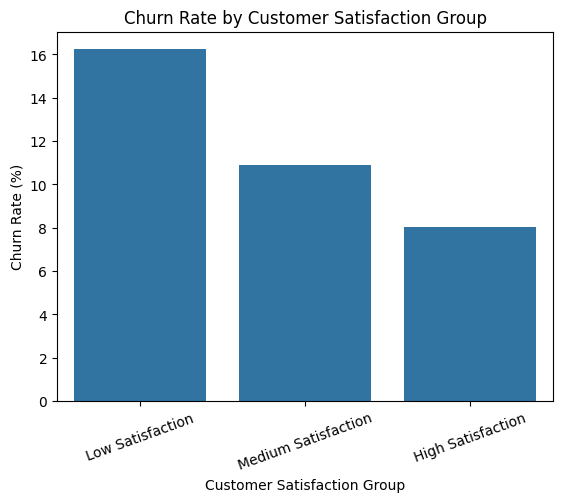

In [20]:
#lets look at how low satisfaction customers churn at a higher rate than high satisfaction customers

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create satisfaction groups
df["satisfaction_group"] = pd.cut(
    df["customer_satisfaction"],
    bins=[0, 2, 6, 9],
    labels=["Low Satisfaction", "Medium Satisfaction", "High Satisfaction"],
    include_lowest=True
)

# Calculate churn rate by satisfaction group
satisfaction_churn = (
    df.groupby("satisfaction_group", observed=True)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean")
    )
    .reset_index()
)

satisfaction_churn["churn_rate"] = satisfaction_churn["churn_rate"] * 100

satisfaction_churn


sns.barplot(
    data=satisfaction_churn,
    x="satisfaction_group",
    y="churn_rate"
)

plt.title("Churn Rate by Customer Satisfaction Group")
plt.xlabel("Customer Satisfaction Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

### Interpretation

This chart shows whether low-satisfaction customers churn at a higher rate than high-satisfaction customers. If the low-satisfaction group has the highest churn rate, customer satisfaction is likely an important retention signal. The business should prioritize dissatisfied customers for support outreach, service improvements, or targeted retention offers.

## Multi-Service Customer Churn

This analysis compares churn rates between customers with multiple services and customers with fewer services. Multi-service customers may be more valuable because they use more products, but they may also churn if their total cost becomes too high or their service experience is poor.

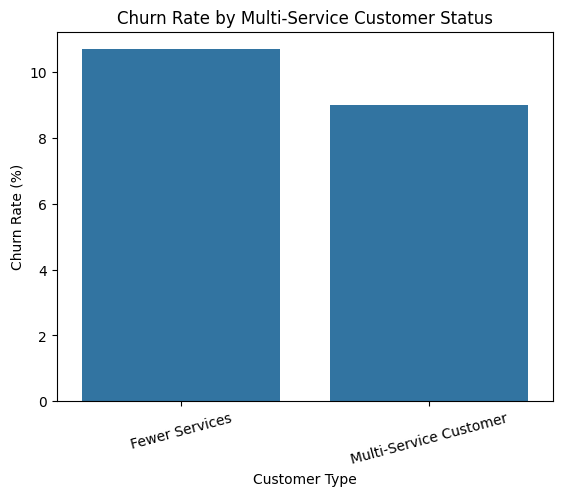

In [21]:
multi_service_churn = (
    df.groupby("is_multi_service_customer")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean"),
        avg_monthly_charges=("monthly_charges", "mean"),
        avg_satisfaction=("customer_satisfaction", "mean")
    )
    .reset_index()
)

multi_service_churn["churn_rate"] = multi_service_churn["churn_rate"] * 100

multi_service_churn["customer_type"] = multi_service_churn["is_multi_service_customer"].map({
    0: "Fewer Services",
    1: "Multi-Service Customer"
})

multi_service_churn



import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=multi_service_churn,
    x="customer_type",
    y="churn_rate"
)

plt.title("Churn Rate by Multi-Service Customer Status")
plt.xlabel("Customer Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.show()

## Interpretation

This showed about the same churn rate

## Does having multiple services effect churn rate?

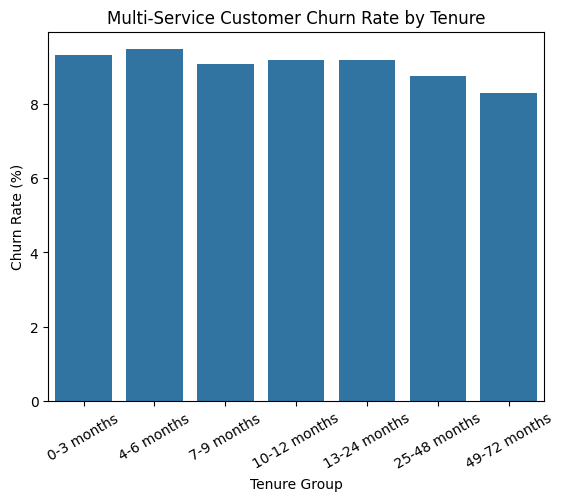

In [22]:
#Now lets look at how tenure affects multi-service customers churn rate
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to multi-service customers only
multi_service = df[df["is_multi_service_customer"] == 1].copy()

# Create tenure groups
multi_service["tenure_group"] = pd.cut(
    multi_service["tenure_months"],
    bins=[0, 3, 6, 9, 12, 24, 48, 72],
    labels=[
        "0-3 months",
        "4-6 months",
        "7-9 months",
        "10-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ],
    include_lowest=True
)

# Calculate churn rate by tenure group
multi_service_tenure_churn = (
    multi_service.groupby("tenure_group", observed=True)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean"),
        avg_monthly_charges=("monthly_charges", "mean"),
        avg_satisfaction=("customer_satisfaction", "mean")
    )
    .reset_index()
)

multi_service_tenure_churn["churn_rate"] = multi_service_tenure_churn["churn_rate"] * 100

multi_service_tenure_churn


sns.barplot(
    data=multi_service_tenure_churn,
    x="tenure_group",
    y="churn_rate"
)

plt.title("Multi-Service Customer Churn Rate by Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

## Interpretation

multi service customers don't have an increased or decreased likelihood of churning

## Churn Rate by Individual Services

This analysis compares churn rates for customers who have each service versus customers who do not. This helps identify which services may be associated with stronger retention or higher churn risk.

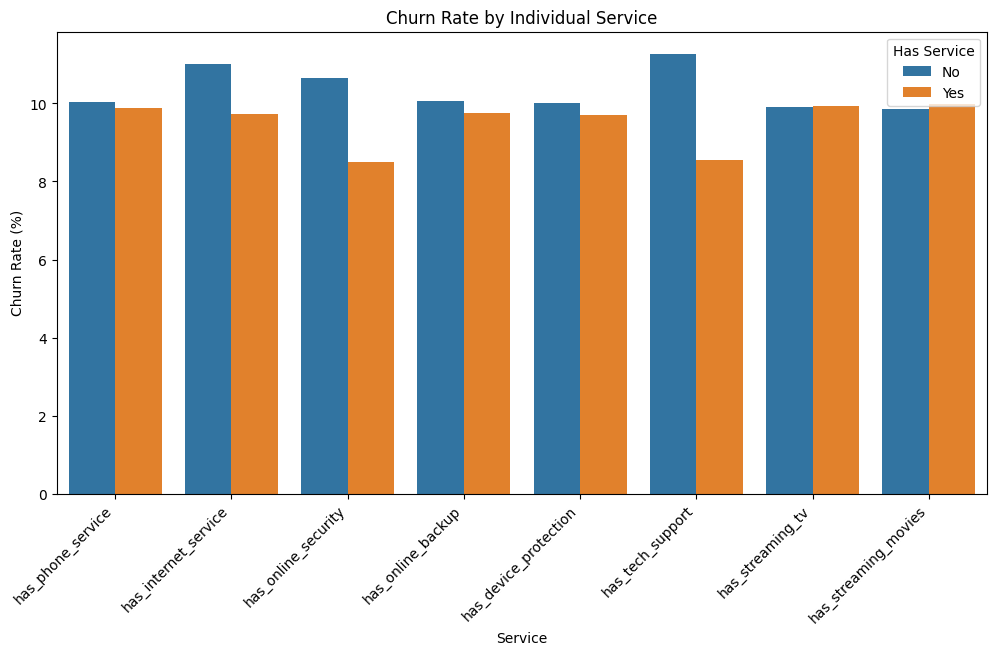

In [23]:
service_cols = [
    "has_phone_service",
    "has_internet_service",
    "has_online_security",
    "has_online_backup",
    "has_device_protection",
    "has_tech_support",
    "has_streaming_tv",
    "has_streaming_movies"
]

service_churn_results = []

for service in service_cols:
    summary = (
        df.groupby(service)
        .agg(
            total_customers=("customer_id", "count"),
            churned_customers=("churn_label", "sum"),
            churn_rate=("churn_label", "mean")
        )
        .reset_index()
    )

    summary["service"] = service
    summary["has_service"] = summary[service].map({0: "No", 1: "Yes"})
    summary["churn_rate"] = summary["churn_rate"] * 100

    service_churn_results.append(
        summary[["service", "has_service", "total_customers", "churned_customers", "churn_rate"]]
    )

service_churn = pd.concat(service_churn_results, ignore_index=True)

service_churn



service_churn_pivot = service_churn.pivot(
    index="service",
    columns="has_service",
    values="churn_rate"
).reset_index()

service_churn_pivot["churn_rate_difference"] = service_churn_pivot["Yes"] - service_churn_pivot["No"]

service_churn_pivot.sort_values("churn_rate_difference", ascending=False)



import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.barplot(
    data=service_churn,
    x="service",
    y="churn_rate",
    hue="has_service"
)

plt.title("Churn Rate by Individual Service")
plt.xlabel("Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Has Service")
plt.show()

## Interpretation

if customer doesn't have tech_support they are around 3% more likely to churn

## Education Level and Churn

This analysis checks whether churn rate differs across customer education levels. Education may be related to income, plan choice, payment behavior, or service expectations, so it is worth exploring as a possible churn segment.

### Business Question
Do customers with different education levels churn at different rates?

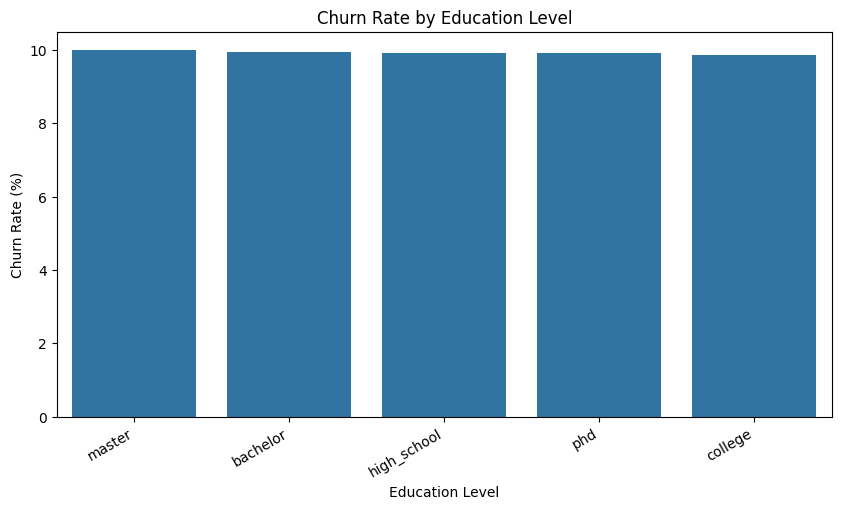

In [24]:
#lets see if education level has an effect on churn rate
education_churn = (
    df.groupby("education")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean"),
        avg_income=("annual_income", "mean"),
        avg_monthly_charges=("monthly_charges", "mean"),
        avg_satisfaction=("customer_satisfaction", "mean")
    )
    .reset_index()
)

education_churn["churn_rate"] = education_churn["churn_rate"] * 100

education_churn.sort_values("churn_rate", ascending=False)


import seaborn as sns
import matplotlib.pyplot as plt

education_churn_sorted = education_churn.sort_values("churn_rate", ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=education_churn_sorted,
    x="education",
    y="churn_rate"
)

plt.title("Churn Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

### Interpretation

This chart compares churn rates across education levels. We can see the churn rate is around the same for all education levels

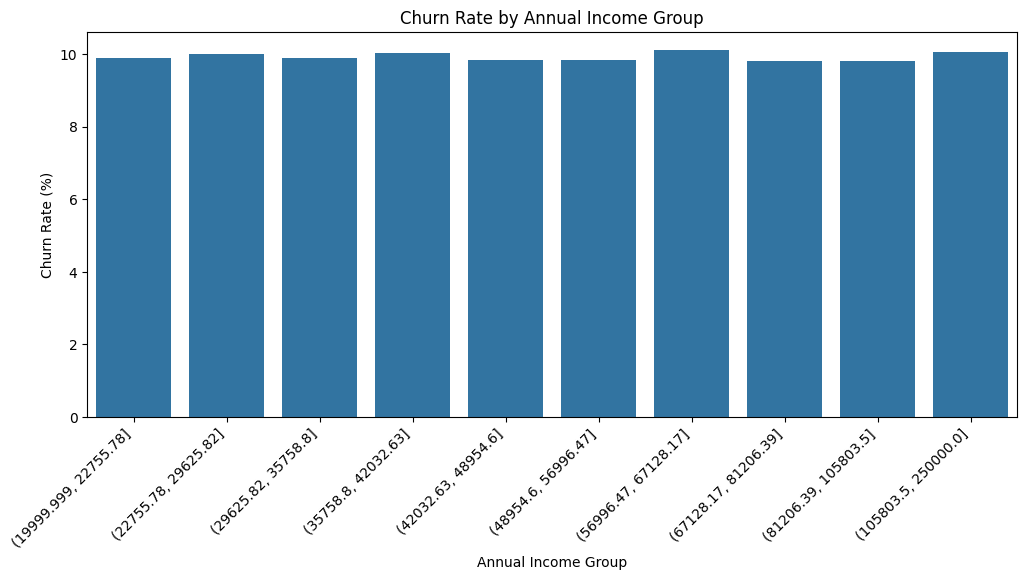

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Remove missing income values for this analysis
income_df = df.dropna(subset=["annual_income"]).copy()

# Create income groups using quantiles
income_df["income_group"] = pd.qcut(
    income_df["annual_income"],
    q=10,
    duplicates="drop"
)

income_churn = (
    income_df.groupby("income_group", observed=True)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean"),
        avg_income=("annual_income", "mean"),
        avg_monthly_charges=("monthly_charges", "mean"),
        avg_satisfaction=("customer_satisfaction", "mean")
    )
    .reset_index()
)

income_churn["churn_rate"] = income_churn["churn_rate"] * 100
income_churn["income_group"] = income_churn["income_group"].astype(str)

income_churn



plt.figure(figsize=(12, 5))

sns.barplot(
    data=income_churn,
    x="income_group",
    y="churn_rate",
)

plt.title("Churn Rate by Annual Income Group")
plt.xlabel("Annual Income Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Interpretation

Annual income groups don't show an increased or decreased likelihood of churning

In [28]:
df["credit_score"].describe()

count    959605.000000
mean        678.562134
std          87.642951
min         300.000000
25%         619.000000
50%         680.000000
75%         740.000000
max         850.000000
Name: credit_score, dtype: float64

## Credit Score and Churn

This analysis compares churn rates across credit score groups. Credit score may be related to payment behavior, late payments, contract eligibility, or customer risk, so it is useful to see whether lower-credit-score customers churn at higher rates.

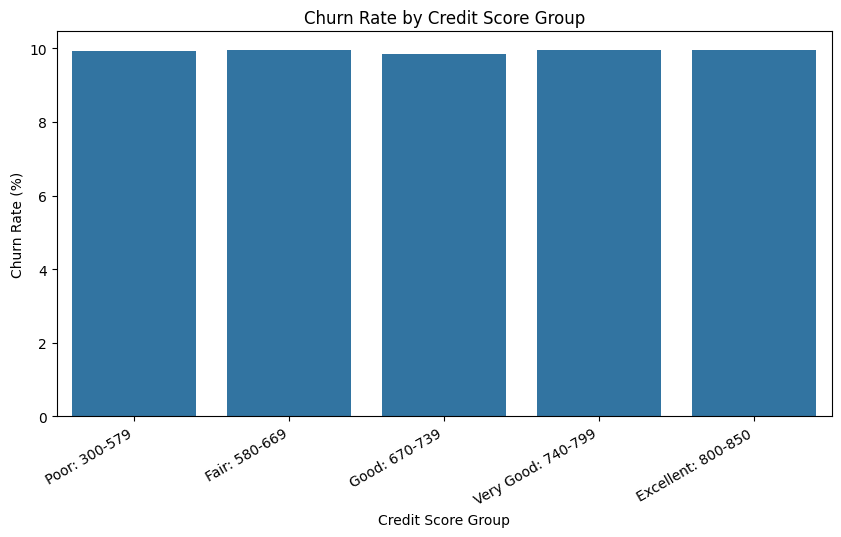

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

credit_df = df.copy()

credit_df["credit_score_group"] = pd.cut(
    credit_df["credit_score"],
    bins=[300, 580, 670, 740, 800, 850],
    labels=[
        "Poor: 300-579",
        "Fair: 580-669",
        "Good: 670-739",
        "Very Good: 740-799",
        "Excellent: 800-850"
    ],
    include_lowest=True
)

credit_churn = (
    credit_df.dropna(subset=["credit_score_group"])
    .groupby("credit_score_group", observed=True)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean"),
        avg_credit_score=("credit_score", "mean"),
        avg_late_payments=("late_payments", "mean"),
        avg_monthly_charges=("monthly_charges", "mean")
    )
    .reset_index()
)

credit_churn["churn_rate"] = credit_churn["churn_rate"] * 100

credit_churn

plt.figure(figsize=(10, 5))

sns.barplot(
    data=credit_churn,
    x="credit_score_group",
    y="churn_rate"
)

plt.title("Churn Rate by Credit Score Group")
plt.xlabel("Credit Score Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

### Interpretation

This chart shows whether churn rate changes across credit score groups. Seems to be no impact on churn rate given credit score

## Does the monthly gb usage effect churn rate?

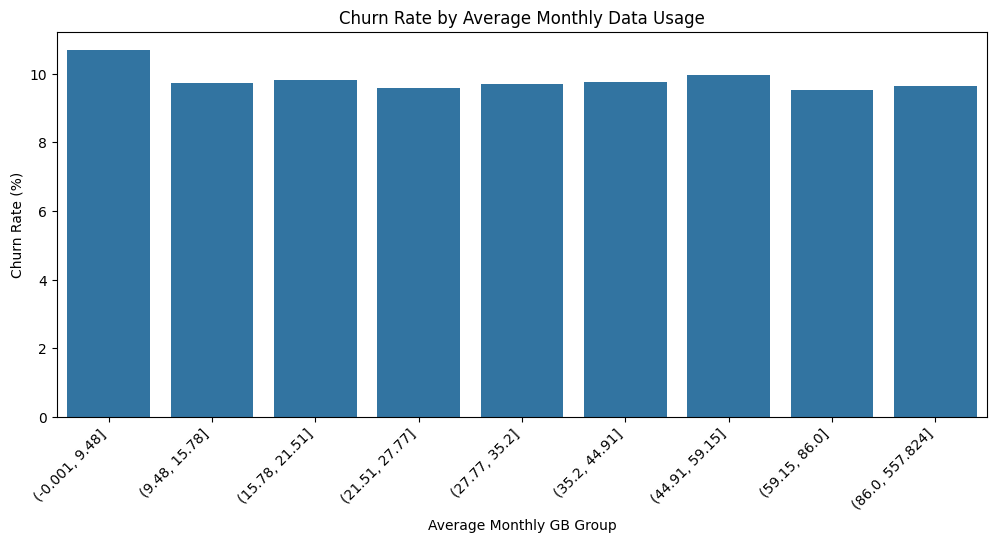

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Drop missing values for this EDA section
usage_df = df.dropna(subset=["avg_monthly_gb"]).copy()

# Create usage groups using quantiles
usage_df["usage_group"] = pd.qcut(
    usage_df["avg_monthly_gb"],
    q=10,
    duplicates="drop"
)

usage_churn = (
    usage_df.groupby("usage_group", observed=True)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean"),
        avg_monthly_gb=("avg_monthly_gb", "mean"),
        avg_monthly_charges=("monthly_charges", "mean"),
        avg_satisfaction=("customer_satisfaction", "mean")
    )
    .reset_index()
)

usage_churn["churn_rate"] = usage_churn["churn_rate"] * 100
usage_churn["usage_group"] = usage_churn["usage_group"].astype(str)

usage_churn

plt.figure(figsize=(12, 5))

sns.barplot(
    data=usage_churn,
    x="usage_group",
    y="churn_rate"
)

plt.title("Churn Rate by Average Monthly Data Usage")
plt.xlabel("Average Monthly GB Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Interpretation

Average montly gb doesn't have an increased or decreased likelihood of churning

## Payment method and Churn

Does the payment method affect churn rate?

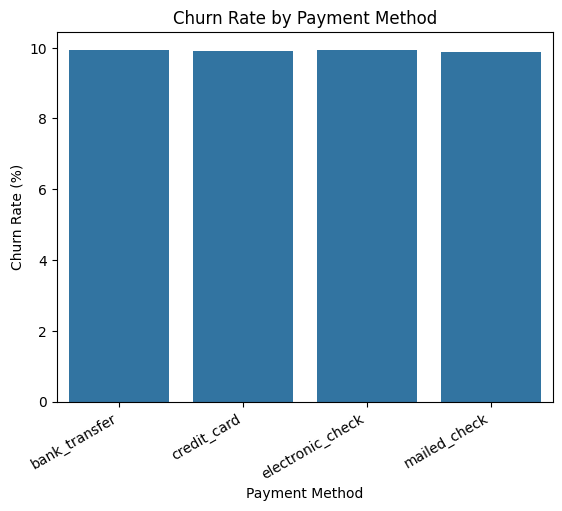

In [31]:
payment_churn = (
    df.groupby("payment_method")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean")
    )
    .reset_index()
)

payment_churn["churn_rate"] *= 100
payment_churn.sort_values("churn_rate", ascending=False)



sns.barplot(data=payment_churn, x="payment_method", y="churn_rate")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

## Interpretation 

Payment method doesn't effect churn rate

## paperless billing

Does paperless billing lead to a higher churn rate?

In [32]:
paperless_churn = (
    df.groupby("paperless_billing")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean")
    )
    .reset_index()
)

paperless_churn["churn_rate"] *= 100
paperless_churn

,paperless_billing,total_customers,churned_customers,churn_rate
0,no,250120,24989,9.990804
1,yes,749880,74238,9.899984


## Interpretation

Paperless billing doesn't effect churn rate


## Complaints

Does the number of complaints effect churn rate?

In [33]:
df["complaint_group"] = pd.cut(
    df["num_complaints"],
    bins=[-1, 0, 1, 2, 5, 100],
    labels=["0", "1", "2", "3-5", "6+"]
)

complaint_churn = (
    df.groupby("complaint_group", observed=True)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean")
    )
    .reset_index()
)

complaint_churn["churn_rate"] *= 100
complaint_churn

,complaint_group,total_customers,churned_customers,churn_rate
0,0,481239,38961,8.095977
1,1,336819,35242,10.463186
2,2,118816,15926,13.403919
3,3-5,33119,6095,18.403333
4,6+,101,34,33.663366


## Interpretation 

Customers with 3 or more complaints are 18% and up more likely to churn

## Late Payments

Do late payments effect churn rate?

In [34]:
late_payment_churn = (
    df.groupby("late_payments")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean")
    )
    .reset_index()
)

late_payment_churn["churn_rate"] *= 100
late_payment_churn.sort_values("late_payments")

,late_payments,total_customers,churned_customers,churn_rate
0,0,669835,60670,9.057454
1,1,268102,29835,11.128227
2,2,54149,7364,13.599512
3,3,7146,1190,16.652673
4,4,709,154,21.720733
5,5,59,14,23.728814


## Interpretation 

With over 3 late payments they are 16% and up to 23% more likely to churn

## Monthly Charges

Does high monthly charges effect churn rate?

In [35]:
charge_df = df.dropna(subset=["monthly_charges"]).copy()

charge_df["monthly_charge_group"] = pd.qcut(
    charge_df["monthly_charges"],
    q=10,
    duplicates="drop"
)

charge_churn = (
    charge_df.groupby("monthly_charge_group", observed=True)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn_label", "sum"),
        churn_rate=("churn_label", "mean"),
        avg_monthly_charges=("monthly_charges", "mean")
    )
    .reset_index()
)

charge_churn["churn_rate"] *= 100
charge_churn["monthly_charge_group"] = charge_churn["monthly_charge_group"].astype(str)

charge_churn

,monthly_charge_group,total_customers,churned_customers,churn_rate,avg_monthly_charges
0,"(19.999, 56.57]",100018,11077,11.075006,47.292925
1,"(56.57, 66.65]",100043,10081,10.076667,61.992335
2,"(66.65, 73.86]",100004,9849,9.848606,70.421828
3,"(73.86, 79.89]",100051,9684,9.679064,76.948212
4,"(79.89, 85.48]",99995,10337,10.337517,82.708451
5,"(85.48, 91.08]",99916,10149,10.157532,88.266193
6,"(91.08, 97.21]",100017,10068,10.066289,94.076301
7,"(97.21, 104.63]",99992,9847,9.847788,100.767726
8,"(104.63, 115.54]",100000,9401,9.401000,109.606791
9,"(115.54, 854.957]",99964,8734,8.737145,132.397027


## Interpretation

No, churn rate doesn't seem to be impacted by monthly charges

## Do missing values mean the customer is more likely to churn?

In [36]:
missing_cols = [
    "annual_income",
    "customer_satisfaction",
    "num_complaints",
    "avg_monthly_gb",
    "credit_score"
]

missing_churn_results = []

for col in missing_cols:
    temp = df.copy()
    temp[f"{col}_missing"] = temp[col].isna().astype(int)

    summary = (
        temp.groupby(f"{col}_missing")
        .agg(
            total_customers=("customer_id", "count"),
            churned_customers=("churn_label", "sum"),
            churn_rate=("churn_label", "mean")
        )
        .reset_index()
    )

    summary["column"] = col
    summary["missing_status"] = summary[f"{col}_missing"].map({0: "Not Missing", 1: "Missing"})
    summary["churn_rate"] *= 100

    missing_churn_results.append(
        summary[["column", "missing_status", "total_customers", "churned_customers", "churn_rate"]]
    )

missing_churn = pd.concat(missing_churn_results, ignore_index=True)
missing_churn

,column,missing_status,total_customers,churned_customers,churn_rate
0,annual_income,Not Missing,970041,96259,9.923189
1,annual_income,Missing,29959,2968,9.906873
2,customer_satisfaction,Not Missing,980079,97272,9.924914
3,customer_satisfaction,Missing,19921,1955,9.813764
4,num_complaints,Not Missing,970094,96258,9.922544
5,num_complaints,Missing,29906,2969,9.927774
6,avg_monthly_gb,Not Missing,949988,94163,9.912020
7,avg_monthly_gb,Missing,50012,5064,10.125570
8,credit_score,Not Missing,959605,95205,9.921270
9,credit_score,Missing,40395,4022,9.956678


## Interpretation

No, the missing values doesn't show that they are churning or not

## Key Findings

1. Senior citizens are more likely to churn compared to non senior citizens

2. if customer satisfaction score is 3 or lower then they are 3-5% more likely to churn

3. month_to_month contract types are 25% likely to churn, the second lowest which is yearly is at 13%

4. month_to_month contracts are more likely to churn when the tenure is between 0-6 months, the churn rate is at around 35%

5. if a customer doesn't have tech_support then they are around 4% more likley to churn compared to people with tech support